
<a id=0> </a>
**AI for Cell Image Analysis** <br>
Dr. Xiao Li xiaoli@pku.edu.cn, 2025 Summer

<span style="font-size:20px">Lab Notebook 01</spam>

_Student name:_<font color = 'blue'> (input your name here)</font> <br>
_Student ID:_<font color = 'blue'> (input your student ID here)</font> <br>

# <span style="font-size:30px"> Lab1. Python and Machine Learning Basics for Image Recognition</span>

In this notebook, you will:
- Warm up and get familiar with Python programming.
- Learn basic machine learning algorithm for classification tasks.
- Load and explore a dataset of handwritten digits.
- Train a Support Vector Machine (SVM) model to classify digit images.
- Evaluate and visualize the performance of your model.

Contents
- [1.1. Introduction to Machine Learning: Binary Classification with Breast Cancer Dataset](#1-1) 
- [1.2. Handwritten Digits Dataset](#1-2) 
- [1.3. Image Recognition: Multiclass Classification](#1-3) 

## 1.0 Set up environment

In [2]:
##You don't need to run this cell if you run this notebook on Bohrium or you have previously installed these libraries

#pip install numpy
#pip install matplotlib
#pip install pandas
#pip install seaborn
#pip install sklearn

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

Matplotlib is building the font cache; this may take a moment.


If you get an error like: </br>
 <font color=red>ModuleNotFoundError: No module named 'numpy'</font></br>
Uncomment corresponding line in the the previous code cell to install required library and import again</br>

## <span d=1-1> 1.1 Introduction to Machine Learning: Binary Classification with Breast Cancer Dataset </span>

The image recognition task is indeed a **classification** problem -- classifying an image as a dog, cat, or butterfly; or classifying if a photo as number of 1, 2 ,3 ... Let's go through fandamental classification algorithms.

Binary classification is the most imple classification task. Binary means there are only two categories. In this notebook, we will use the Breast Cancer Wisconsin dataset from `sklearn`, which contains features computed from digitized images of breast mass cells. The task is to predict whether the mass is malignant (cancerous) or benign (non-cancerous) -- a typical binary classification problem.

Utilizing sklearn Breast Cancer dataset, you will learn to train a machine learning model using **logistic regression** and to evaluate your model's performance.

In [4]:
#Load required breast cancer data set and other required libaries
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [5]:
# Load the dataset
cancer = load_breast_cancer()#ditionary-like object
#View what the data look like
#print(cancer)

### **Explore the Data**🔍 <br>

The dataset contains eight key:value pairs, of which .data, .target, .target_names, feature_names are most important. The value for 'frame" is none.

Observe how many rows and columns does the sklearn breast cancer dataset contains. The number corresponds to # samples (cells) and # features. <br>

The features' names are stored in cancer.feature_names. <br>

In [6]:
#Review the keys in the breas cancer dataset:
for key in cancer:
    print(key)

data
target
frame
target_names
DESCR
feature_names
filename
data_module


In [7]:
print(cancer.feature_names) #run this command to see what are the features

['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


In [8]:
#store the data in a pandas dataframe for clearer view of the data 
cancer_df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
cancer_df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


How many columns are in the dataframe? Note #columns = # of features.

The cancer.target contains the label of each breast cell being either "0" (malignant) or "1" (benign). 

Append the lable to the dataframe:

In [9]:
cancer_df['target'] = cancer.target
# 0 = malignant, 1 = benign
cancer_df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0


✅ **TODO:** <br>
How many columns are in the dataframe? What's the data size of the dataset? (How many rows) <br>
Note: # columns = # features + 1 target <br>






Let's look at how many samples we have in each category.

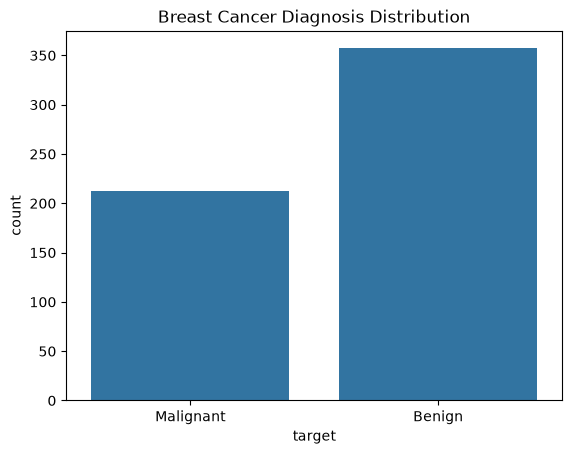

In [10]:
sns.countplot(x='target', data=cancer_df)
plt.xticks([0, 1], ['Malignant', 'Benign'])
plt.title('Breast Cancer Diagnosis Distribution')
plt.show()

You can see the number of malignant and benign cases. This gives us an idea of the class distribution.

### **Process the Data**🔍 <br>

Now let's split our data into training and testing sets using the sklearn train_test_split function. This function split data with a random module into train and test set in a size set by the user. <br>

A classification model will be trained using the train set, and the test set helps us evaluate how well the model generalizes to unseen data.

In [11]:
cancer_X = cancer_df.drop('target', axis=1) #.drop cuts out the target column
cancer_y = cancer_df['target']

#test_size=0.2 means 20% of the data is split into the test set
cancer_X_train, cancer_X_test, cancer_y_train, cancer_y_test = train_test_split(cancer_X, cancer_y, test_size=0.2, random_state=42)

print("Training set size:", cancer_X_train.shape)
print("Test set size:", cancer_X_test.shape)

Training set size: (455, 30)
Test set size: (114, 30)


We can see that the values of varoius features are in various ranges. For example, the mean radius has a value around 10~20, the mean perimeters are around ~120, while the mean fractal dimensions are in the range of ~0.0500... <br>

Before training the machine learning model, We need to scale features so that they all have similar ranges, e.g, 0~1, or -1~1. This is important for most supervised learning models to perform well. 

Sklearn has several built in scaler function. StandardScaler() standardizes features by removing the mean and scaling to unit variance to make sure the values are normally distributed with zero mean and unit variance.

The standardized value of a sample ( x ) is calculated as: $ x' = \frac{x - \mu}{\sigma}$

where $\mu$ is the mean of the training samples and $\sigma$ is the standard deviation of the training samples.

In [12]:
scaler = StandardScaler()
cancer_X_train_scaled = scaler.fit_transform(cancer_X_train)
cancer_X_test_scaled = scaler.transform(cancer_X_test)
print(cancer_X_test_scaled) #observe the features are scaled to have a 0 mean 

[[-0.46649743 -0.13728933 -0.44421138 ... -0.19435087  0.17275669
   0.20372995]
 [ 1.36536344  0.49866473  1.30551088 ...  0.99177862 -0.561211
  -1.00838949]
 [ 0.38006578  0.06921974  0.40410139 ...  0.57035018 -0.10783139
  -0.20629287]
 ...
 [-0.73547237 -0.99852603 -0.74138839 ... -0.27741059 -0.3820785
  -0.32408328]
 [ 0.02898271  2.0334026   0.0274851  ... -0.49027026 -1.60905688
  -0.33137507]
 [ 1.87216885  2.80077153  1.80354992 ...  0.7925579  -0.05868885
  -0.09467243]]


### **Train a Logistic Regression Model**🤖 <br>

**📘 Logistic regression** is a simple yet powerful algorithm used to classify data into one of two categories. In our case, we are predicting whether a breast tumor cell is:

- `0` = Malignant (cancerous), or  
- `1` = Benign (non-cancerous)

⚙️ How Does It Work?

Logistic regression works by learning the best way to combine the input features (e.g., radius, texture, symmetry, etc.) into a single number, and then converting that number into a probability, from 0~1.

1. **Linear Combination of Features**

Each tumor sample has multiple features: $x_{1}, x_{2}, \cdots x_{n}$. Logistic regression computes a weighted sum $z$ of these features:

$z = w_{1} x_{1} + w_{2} x_{2} + \cdots + w_{n} x_{n} + b$ 

Where:
- $x_{1}, x_{2}, \dots, x_{n}$ are the feature values. n=569 in breast cancer dataset case.
- $w_{1}, w_{2}, \dots, w_{n}$ are weights/parameters obtained or 'learned' from training.
- $b$ is a intercept term.

2. **Apply the Sigmoid Function**

To convert this sum into a probability between 0 and 1, we use the **sigmoid function**:

$y = \frac{1}{1 + e^{-z}}$

<img src="./img/logistic_sigmoid.png" alt="sigmoid function" style="width: 500px"/>

- $y$ is the predicted probability that the tumor is **benign**.
- A value close to 1 → likely benign  
- A value close to 0 → likely malignant

3. **Make a Prediction**

We use a threshold (commonly 0.5) to decide the class:

- If $y>0.5$, predict **benign (1)**
- If $y \leq 0.5$, predict **malignant (0)**


scikit-learn has a built-in logistic regression function that we can directly call to achieave the purpose.

In [13]:
cancer_model = LogisticRegression()
cancer_model.fit(cancer_X_train_scaled, cancer_y_train)

UnicodeDecodeError: 'gbk' codec can't decode byte 0x94 in position 2952: illegal multibyte sequence

UnicodeDecodeError: 'gbk' codec can't decode byte 0x94 in position 2952: illegal multibyte sequence

LogisticRegression()

### **Evaluate the Model**<br>

Let's see how well our model performs on the test set.

In [ ]:
cancer_y_pred = cancer_model.predict(cancer_X_test_scaled)

print("Accuracy Score:", accuracy_score(cancer_y_test, cancer_y_pred))
#print("\nClassification Report:\n", classification_report(cancer_y_test, cancer_y_pred))

# Confusion matrix
cancer_conf_mat = confusion_matrix(cancer_y_test, cancer_y_pred)

sns.heatmap(cancer_conf_mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Malignant', 'Benign'],
            yticklabels=['Malignant', 'Benign'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

- Accuracy is the percentage of samples that were correctly classified.
- The confusion matrix shows the number of true and false predictions.

In summary, we have gone through the basic workflow of machine learning:
> **Data Processing** (splitting, scaling) → **Train** → **Predict** → **Evaluate**.

[back to top](#0)

## **<span style="font-size:20px" id=1-2> 1.2 Handwritten digits dataset </span>**

Let's move on to start learning image recognition using machine learning. We will use the optical Recognition of Handwritten Digits dataset made by UC Irvine for machine learning. The data set can be imported from sklearn library directly.

In [ ]:
from sklearn.datasets import load_digits
digits = load_digits()

### **Explore the Data** <br>
`load_digits` dataset is also a dictionary-like Python object similar to the load_breas_cancer set.

In [ ]:
type(digits)  #ditionary-like object

In [ ]:
for key in digits:
    print(key)

Explore the dataset to see how may images are there, and what is the resolution of each image? The handwritten images are stored in the _image_ attribute of the dataset.

In [ ]:
print(f"data shape of images: {digits.images.shape}")
print(f"data shape of each image: {digits.images[0].shape}")

Let's print the 8x8 matrix represneting one image.

2D arrays represent grayscale images in machine learning tasks. Each element of the array represents a pixel of the array. The pixel values range from 0 to 16, where 0 stands for black and 16 represents a white pixel.<br>

In [ ]:
print((f"matrix representing an image:\n {digits.images[0]}")) 
#change the image index to show the matrix for images other than image 0

We can use the matplotlib imshow() function (plt.image()) to visualize a 2D array.

In [ ]:
plt.imshow(digits.images[0])
cbar = plt.colorbar()
plt.show()

The defualt color map of plt.imshow() is 'viridis'. <br>
Now, lets change the color map from the default to grayscale "gray". <br>

In [ ]:
plt.imshow(digits.images[0],cmap="gray")
cbar = plt.colorbar()
plt.show()
#TODO change the image index to show other images

Each sample has 8x8=64 features. 'pixel_0_2' represents the pixel in the first row and third column. Recall that python array index starts at 0.

In [ ]:
plt.imshow(digits.images[149],cmap="gray")
cbar = plt.colorbar()
plt.show()

In [ ]:
print(len(digits.feature_names))
print(digits.feature_names)

✅ **TODO:** 
1. Check and visualize the 250th image (index=149).<br>
2. Make a matrix showing Chinese character "二" or other characters by yourself:

In [ ]:
#make a matrix showing Chinese character "十" by yourself:
#first we generate a 8x8 matrix with all elements equals to 0
newImg=np.zeros((8, 8))
print(newImg)

In [ ]:
##modify newImg matrix to show the designated character
#
newImg=np.array([[ 0.,  0.,  0., 0.,  0.,  0.,  0.,  0.],
                 [ 0.,  0., 0., 0., 0., 0.,  0.,  0.],
                [ 0.,  0.,  0., 0.,  0.,  0.,  0.,  0.],
                 [ 0.,  0.,  0., 0.,  0.,  0.,  0.,  0.],
                 [0.,  0.,  0., 0.,  0.,  0.,  0.,  0.],
                 [ 0.,  0.,  0., 0.,  0.,  0.,  0.,  0.],
                 [0.,  0.,  0., 0.,  0.,  0.,  0.,  0.],
                [ 0.,  0.,  0., 0.,  0.,  0.,  0.,  0.]])
#
#
plt.imshow(newImg,cmap="gray")
plt.show()

The identities or the lables of iamges are stored in the _target_ attribute of the dataset. Fetch the target labels and print the size and the values. There 1797 targets, which is consistant with the total number of images.

In [ ]:
print(digits.target.shape)
print(digits.target) 

Visualize the first 10 images. <br>

In [ ]:
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    #TODO Change the interpolation method to "bilinear" and observe the difference. 
    plt.imshow(digits.images[i], cmap='gray',interpolation='none') 
    plt.title(f"target: {digits.target[i]}")
    plt.axis('off')
plt.suptitle("Sample Digit Images", fontsize=10)
plt.show()

✅ Change the interpolation method to "bilinear" and observe the difference. Describe the difference. <br> 

 Observations: <font color='blue'> 


 </font>


[back to top](#0)

## **<span style="font-size:20px" id=1-3> 1.3 Image Recognition: Multiclass Classification </span>**

The task of recognizing handritten digits is actually a multiclass classification problem -- we need to classify each image into ten categories: 0, 1, 2, 3, 4, 5, 6, 7, 8. 9. <br>

In the previous binary classification task, we used logistic regression model. For Multiclass classification problem, another machine learning method called **support vector machine (SVM)** method is of good choice. 

### **Process the Data** <br>
Step 1 of applying machine learning is preparing data for training. Similar to logistic regression, SVM is a supervised learning algorithm, so we also need to split the dataset into train and test sets.

Data for features and targets need to extracted and stored in proper format and shape. In the case of the load_digits set, wehave 1797 samples, and each sample has 64 features (values for 8x8 pixels). As a result we need to have an array of size (1797,64) to store the features, and a 1D array of 1797 elements to store the targets.  <br>

<img src="./img/ML_digits.png" alt="ML_digits" style="width: 700px"/>

In [ ]:
# X: input data (features) , y: targets
digits_X = digits.data
#digits.data.shapre = (1797,64), containing flattend image pixel data 
digits_y = digits.target

# Split into training (75%) and testing (25%)
digits_X_train, digits_X_test, digits_y_train, digits_y_test = train_test_split(digits_X, digits_y, test_size=0.25, random_state=42)

print(f"Training samples: {len(digits_X_train)}")
print(f"Testing samples: {len(digits_X_test)}")

### Train a Support Vector Machine (SVM) Model

Step 3 is to train a ML model. We train a classifier by adopting the SVC method for this task.

📘 A **Support Vector Machine (SVM)** is a type of supervised learning ML algorithm used for classification tasks. 

Core Idea of SVM: SVM tries to find the _best boundary (called a hyperplane)_ that separates data points of different classes. In the case of SVM, a data point is viewed as a $p$-dimensional vector, and we want to know whether we can separate data points with a $p-1$-dimensional hyperplane.  For 2D data (data with only 2 features), this boundary is just a line. For 3D data, it's a 2D surface. For higher dimensions, the boundary is a more complex shape.

The goal of SVM is to:

- Maximize the margin, which is the distance between the hyperplane and the nearest data points from each class.
- These nearest points are called _support vectors_ — they "support" the boundary.

Linear vs Nonlinear SVM

- Linear SVM works well when the data can be separated by a straight line.
- Nonlinear SVM uses a technique called the _kernel trick_ to create more flexible boundaries for data that isn’t linearly separable.

In our case, we use a **Radial Basis Function (RBF) kernel**, which is good at handling curved decision boundaries.

⚙️ How Does SVM Work for Image Classification?

1. Each image (e.g., 8×8 pixels) is flattened into a vector (length 64).
2. The SVM tries to find the boundary that best separates each digit class (0–9).
3. When given a new image, SVM:
   - Places the point in the 64-dimensional space.
   - Determines on which side of the decision boundary it lies.
   - Predicts the class accordingly.

To apply SVC, two important parameters need to be tuned and set at proper values. Gamma and C controls the shape and behavior of the decision boundary.

| Parameter | Typical Range          |
|-----------|------------------------|
| `C`       | 0.01 to 1000           |
| `gamma`   | 1e-6 to 10             |

You can tune these values using techniques like Grid Search or cross-validation to find the best settings for your specific dataset.

| Parameter | Meaning | Smaller Value | Larger Value |
|---|---|---|---|
| `C`  | Penalty for training errors | More tolerant of errors; wider margin and stronger regularization; may underfit | Less tolerant of errors; prioritizes training accuracy; may overfit |
| `C`  | Influence radius of each training sample in the RBF kernel | Each sample has a wider influence; smoother decision boundary; may underfit | Each sample has a narrower influence; more complex decision boundary; may overfit |

Both parameters need to be balanced to create a model that generalizes well to new data.

We have chosen the ideal gamma and C values for you this time. 

In summary, SVM is suitable for classifying tasks when:
- The number of features (like pixels) is large.
- You want a model that balances accuracy and efficiency.


In [ ]:
from sklearn import svm
svc_model = svm.SVC(gamma=0.001, C=100) #the SVC method of svm creates a support vector classification

In [ ]:
svc_model.fit(digits_X_train, digits_y_train)

### Predict and Evaluate

Make predictions to test how well our trained model performs on the test data.

In [ ]:
digits_y_pred = svc_model.predict(digits_X_test)

Let’s view a few predictions:

In [ ]:
plt.figure(figsize=(10, 3))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(digits_X_test[i].reshape(8, 8), cmap='gray')
    plt.title(f"Pred: {digits_y_pred[i]}\nTrue: {digits_y_test[i]}")
    plt.axis('off')
plt.suptitle("Model Predictions vs True Labels", fontsize=14)
plt.show()


Step 4 is to evaluate the model performance. We can use a confusion matrix and a classification report to evaluate accuracy, precision, and recall.

In [ ]:
print("Classification Report:")
print(classification_report(digits_y_test, digits_y_pred))

print("Confusion Matrix:")
digits_conf_mat = confusion_matrix(digits_y_test, digits_y_pred)
print(digits_conf_mat)

Similarly, we can print the confusion matrix, which tells the accuracy of a certain classification.

The confusion matrix can be plotted for more intuitive illustration called "heatmap" using seaborn:

In [ ]:
sns.heatmap(digits_conf_mat, annot=True, cmap="crest", cbar=True)
plt.xlabel('True Value')
plt.ylabel('Predicted Value');

✅ **TODO:** 

Test the trained classifier using your own data. 

Hand write a digit with black maker on a piece of white paper. Take a photo by your phone and upload the photo 

In [ ]:
#install opencv for image processing if it hasn't been installed before
#pip install opencv-python
#pip install opencv-python

In [ ]:
import cv2

In [ ]:
# Read the image and store the data in variables
my_img = cv2.imread('./img/digit8_photo.jpg') #insert your image file path
my_img_rgb=cv2.cvtColor(my_img, cv2.COLOR_BGR2RGB) 

In [ ]:
plt.imshow(my_img_rgb) # use matplotlib imshow to show image
plt.axis('off') #turn off axis
plt.show()

In [ ]:
# define a function to process the image
def preprocess_image_for_digit(img_path):
    # Load in grayscale
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    
    # Resize to 8x8 after cleaning
    my_img = cv2.bitwise_not(img)  # Invert: background white, digit black
    my_img = cv2.resize(my_img, (8, 8), interpolation=cv2.INTER_AREA)
    
    # Normalize to match the digits dataset (0-16)
    my_img = my_img / 255.0 * 16
    my_img = my_img.astype(np.float64)
    
    # Flatten to shape (1, 64) as model expects
    my_img_flat = my_img.reshape(1, -1)
    
    return my_img_flat, my_img

Show the grayscale 8x8 image of your handwritten digit. Insert your own code below to complete this task.

In [1]:
# Convert your image to a 8x8 matrix
img_path = 'img/8.jpg' # insert your image file path
input_flat, input_8x8 = preprocess_image_for_digit(img_path)

# Visualize the preprocessed image
#
#


NameError: name 'preprocess_image_for_digit' is not defined

You've got a 8x8 input_8x8 matrix that prepresents the image you drew by yourself. You also got a input_flat array that contains the 64 pixels in a 1D array.

In [ ]:
print((f"input_8x8 shape: {input_8x8.shape}")) 
print((f"input_flat shape: {input_flat.shape}")) 

Use the svc model you trained previously to recognize your handwritten digit. Does the model make correct prediction?

In [ ]:
#Write your own code below to recognize your or classmate's handwritten digit
#
#
#


**References** <br>
- Scikit-learn for machine learning: https://pm.jh.edu/cookbook/PythonDataScienceHandbook/notebooks/05.02-Introducing-Scikit-Learn.html <br>
- load_breast_cancer: https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html <br>
- load_digits: https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_digits.html<br>
- Support Vector Classifier: https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html <br>
- colormaps: https://matplotlib.org/stable/users/explain/colors/colormaps.html <br>
- interpolation methods: https://matplotlib.org/3.0.0/gallery/images_contours_and_fields/interpolation_methods.html


[back to top](#0)